In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# **Task 1**
You are given the dataset:

Data=[12,15,20,21,21,22,25,30,30,32,40]


Your tasks:
Mean: Calculate the mean of the dataset.

Median: Find the median.

Mode: Identify the mode(s).

Write a short note comparing the three values — what do they tell you about the dataset’s distribution?

In [12]:
from scipy import stats
import statistics

data=[12,15,20,21,21,22,25,30,30,32,40]
print("Mean",np.mean(data))
print("Median",np.median(data))
print("Mode",stats.mode(data,keepdims=True)) #Older version-> captures only the first mode
print("Mode",statistics.mode(data)) #returns only the first mode it encounters
print("Mode",pd.Series(data).mode()) #returns all modes

Mean 24.363636363636363
Median 22.0
Mode ModeResult(mode=array([21]), count=array([2]))
Mode 21
Mode 0    21
1    30
dtype: int64


*  Mean>Median -> There is a chance of right skewness being present(needs to be checked with visualization)
*  2 modes present(21,30) and hence the data set is bimodal that suggests two clusters or peaks in the dataset
*  No significant outliers and hence mean can be considered as a good measure of centrality

<Axes: ylabel='Count'>

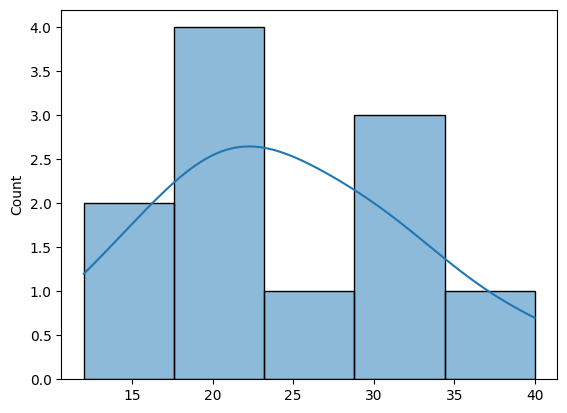

In [21]:
sns.histplot(data=data,bins=5,kde=True)

# **Task 2**
Using the same dataset:

Data=[12,15,20,21,21,22,25,30,30,32,40]

Your tasks:
Range: Find the difference between the maximum and minimum values.

Interquartile Range (IQR): Calculate Q3 − Q1.

Variance: Compute the variance of the dataset.

Standard Deviation: Calculate the standard deviation.

Write a short note on what these measures tell you about the spread of the data compared to the central tendency values you calculated earlier.

In [23]:
data=[12,15,20,21,21,22,25,30,30,32,40]
print("Range", max(data)-min(data))

q1=np.percentile(data,25)
q3=np.percentile(data,75)
iqr=q3=q1
print("Interquartile range", iqr)

print("Variance", np.var(data))
print("Standard deviation", np.std(data))

Range 28
Interquartile range 12.075
Variance 59.50413223140497
Standard deviation 7.713892158398701


*  The large range vs. smaller IQR hints at possible outliers. Most of the data is concentrated, but a few points may be far away.

*  The standard deviation being smaller than half the range also supports this idea: dispersion is moderate overall, but extremes exist.

# **Task 3**

Perform box plot analysis on the dataset

Calculate outliers using iqr and zscore method

Run tests to show if the data is normally distributed

Compute skewness coefficient


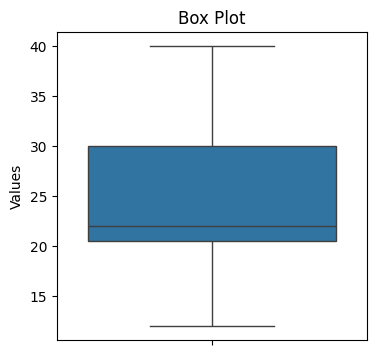

In [27]:
plt.figure(figsize=(4,4))

sns.boxplot(data)
plt.ylabel("Values")
plt.title("Box Plot")
plt.show()

In [25]:
outliers=[x for x in data if x< q1-1.5*iqr or x>q3+1.5*iqr]
outliers

[32, 40]

In [38]:
z_score=[]
for i in data:
  z_score.append(np.abs((i-np.mean(data))/np.std(data)))

print(z_score)

indexes=[x for x,z in enumerate(z_score) if z > 3]

for j in indexes:
  print(data[j])

[np.float64(1.6027753706895076), np.float64(1.2138666410369066), np.float64(0.5656854249492379), np.float64(0.43604918173170426), np.float64(0.43604918173170426), np.float64(0.3064129385141705), np.float64(0.08249579113843059), np.float64(0.7306770072260991), np.float64(0.7306770072260991), np.float64(0.9899494936611665), np.float64(2.027039439401436)]


**Test for normality**

<Axes: ylabel='Count'>

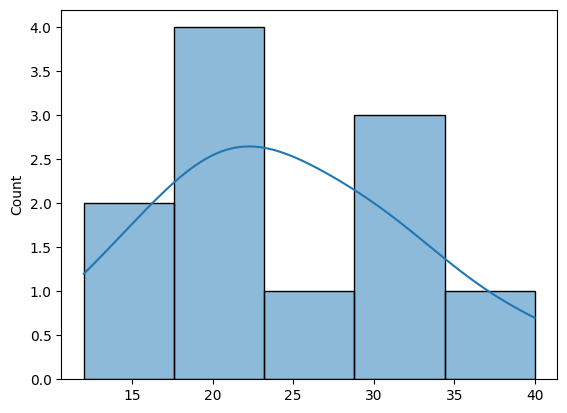

In [39]:
sns.histplot(data=data, kde=True)

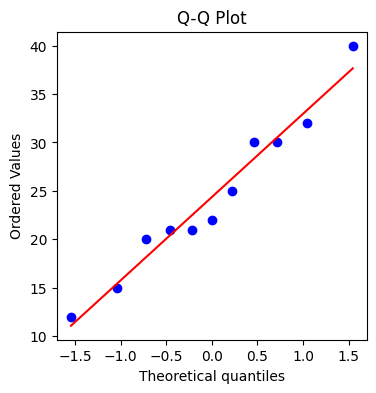

In [43]:
import scipy.stats as stats

plt.figure(figsize=(4,4))
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

Points close to the line → your data is approximately normal.

Systematic curve (S-shape) → data is skewed.

Concave upward → right-skewed (long tail to the right).

Concave downward → left-skewed (long tail to the left).

Heavy tails (points far above/below at ends) → data has more extreme values than a normal distribution (leptokurtic).

Compressed tails (points closer to the line at ends) → data has fewer extremes than normal (platykurtic).

**(H₀): “The data is normally distributed.”**

p > 0.05 → Fail to reject H₀.

Your data does not show significant evidence against normality.

In plain terms: the data could be normal.

p ≤ 0.05 → Reject H₀.

Your data significantly deviates from normality.

In plain terms: the data is unlikely to be normal.

In [44]:
from scipy.stats import shapiro

stat, p = shapiro(data)
print("Shapiro-Wilk Test p-value:", p)

Shapiro-Wilk Test p-value: 0.8431717741191056


In [46]:
from scipy.stats import normaltest

stat, p = normaltest(data)
print("D’Agostino and Pearson Test p-value:", p)

D’Agostino and Pearson Test p-value: 0.8040855362199157


In [49]:
from scipy.stats import kstest

stat, p = kstest(data, 'norm', args=(np.mean(data), np.std(data)))
print("Kolmogorov-Smirnov Test p-value:", p)

Kolmogorov-Smirnov Test p-value: 0.8755928885678073


**Skewness**

In [50]:
from scipy.stats import skew

print("Skewness coefficient",skew(data))

Skewness coefficient 0.3452939905519141


Skewness ≈ 0 → distribution is symmetric (normal‑like).

Positive skew (> 0) → right‑skewed (long tail to the right).

Negative skew (< 0) → left‑skewed (long tail to the left).

Rule of thumb:

|skewness| < 0.5 → fairly symmetric

0.5–1 → moderate skew

1 → highly skewed

# **Task 4:**

Check for following parametric assumptions on the given dataset

* Normality of residuals
* Homoscedasticity
* Linearity(linear relationship)
* No multicollinearity

In [70]:
data = pd.DataFrame({
    "Group": ["A","A","A","A","A","B","B","B","B","B"],
    "Score": [12, 15, 14, 13, 16, 22, 25, 24, 23, 26]
})
data

,Group,Score
0,A,12
1,A,15
2,A,14
3,A,13
4,A,16
5,B,22
6,B,25
7,B,24
8,B,23
9,B,26


**Normality of residuals**

In [71]:
from scipy.stats import shapiro

statA, pA= shapiro(data[data['Group']=='A']['Score'])
statA, pB= shapiro(data[data['Group']=='B']['Score'])

print("Shapiro-Wilk p-values for group A", pA)
print("Shapiro-Wilk p-values for group B", pB)

Shapiro-Wilk p-values for group A 0.9671739349728582
Shapiro-Wilk p-values for group B 0.9671739349728582


Data is normally distributed

**Homogeneity of variance**

Ho->Variance is homogeneous
H1-> Variance is not homogeneous

In [72]:
from scipy.stats import levene

stat,p =levene(data[data['Group']=='A']['Score'], data[data['Group']=='B']['Score'])
print(p)

1.0


Since p-value>0.05 : Accept Ho

((array([-1.12899754, -0.48565271,  0.        ,  0.48565271,  1.12899754]),
  array([22, 23, 24, 25, 26])),
 (np.float64(1.816391063055823),
  np.float64(24.0),
  np.float64(0.9983523729245841)))

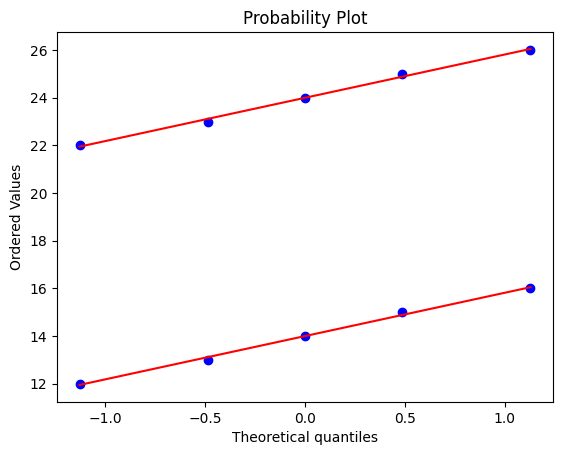

In [73]:
import scipy.stats as stats
stats.probplot(data[data['Group']=='A']['Score'],dist='norm',plot=plt)
stats.probplot(data[data['Group']=='B']['Score'],dist='norm',plot=plt)

**Check for linearity**

In [75]:
import pandas as pd

data = pd.DataFrame({
    "Hours_Studied": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "Score": [50, 55, 57, 60, 62, 65, 68, 72, 75, 78]
})

print(data)

   Hours_Studied  Score
0              2     50
1              3     55
2              4     57
3              5     60
4              6     62
5              7     65
6              8     68
7              9     72
8             10     75
9             11     78


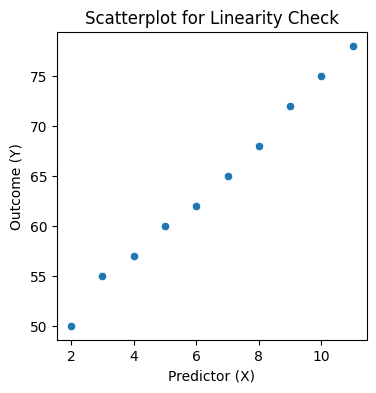

In [76]:
plt.figure(figsize=(4,4))
sns.scatterplot(data=data, x=data['Hours_Studied'], y=data['Score'])
plt.xlabel("Predictor (X)")
plt.ylabel("Outcome (Y)")
plt.title("Scatterplot for Linearity Check")
plt.show()

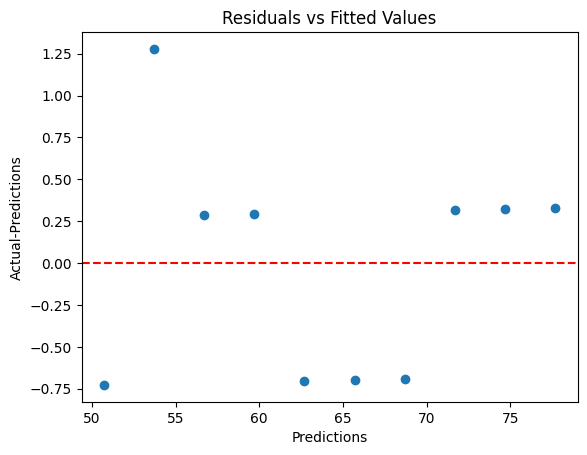

In [78]:
import statsmodels.api as sm

X = sm.add_constant(data["Hours_Studied"])
model = sm.OLS(data["Score"], X).fit()

fitted_vals = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predictions")
plt.ylabel("Actual-Predictions")
plt.title("Residuals vs Fitted Values")
plt.show()


**Random scatter around 0 (no pattern)**

* Assumptions of linearity and homoscedasticity (equal variance) are satisfied.

* Your model is appropriate.

**Curved pattern (U-shape, inverted U, etc.)**

* Suggests non-linearity.

* The relationship between predictors and outcome isn’t purely linear.

**Funnel shape (residuals spread wider at one end)**

* Indicates heteroscedasticity (unequal variance).

* Violates parametric assumptions.

**Clusters or bands**

* May suggest dependence or missing variables.

Linearity exists in our data

**Test for multicollinearity**

In [83]:
print(data.corr())

               Hours_Studied     Score
Hours_Studied       1.000000  0.997241
Score               0.997241  1.000000


<Axes: >

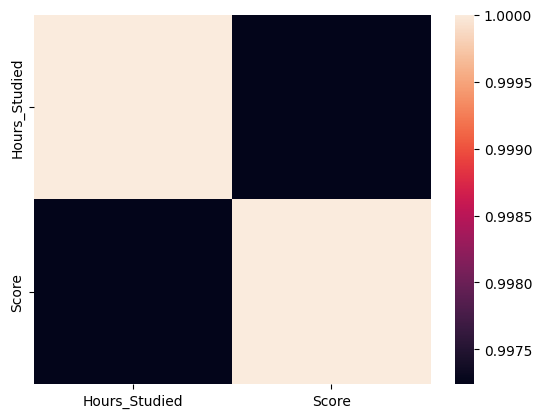

In [87]:
sns.heatmap(data=data.corr())

# **Hypothesis Testing**

# **Task 1: One-Sample t-test**
Scenario: A company claims the average delivery time is 30 minutes.

You collect a sample of 40 deliveries with a mean of 32 minutes and SD of 5.

Null hypothesis: μ = 30

Alternative hypothesis: μ ≠ 30

In [90]:
from scipy.stats import ttest_1samp

sample_mean = 32
sample_std = 5
n = 40
mu0 = 30

# Manual calculation
t_stat = (sample_mean - mu0) / (sample_std / np.sqrt(n))
print("t-statistic:", t_stat)

# Using scipy
data = np.random.normal(loc=32, scale=5, size=40)  # simulated sample
t_stat, p_val = ttest_1samp(data, mu0)
print("t-statistic:", t_stat, "p-value:", p_val)

t-statistic: 2.5298221281347035
t-statistic: 2.670083485657392 p-value: 0.010999527063014559


# **Task 2: Two-Sample t-test**
Scenario: You want to test if two teaching methods produce different average scores.

Group A: mean = 75, SD = 8, n = 30

Group B: mean = 80, SD = 10, n = 35

H₀: μA = μB

H₁: μA ≠ μB

In [91]:
from scipy.stats import ttest_ind

# Simulated data based on given stats
groupA = np.random.normal(loc=75, scale=8, size=30)
groupB = np.random.normal(loc=80, scale=10, size=35)

t_stat, p_val = ttest_ind(groupA, groupB, equal_var=False)  # Welch’s t-test
print("t-statistic:", t_stat, "p-value:", p_val)


t-statistic: -1.1768145868597513 p-value: 0.24376324499680205


# **Task 4: Chi-Square Test**
Scenario: You survey 100 people about preferred drink (Tea vs Coffee).

Observed: Tea = 60, Coffee = 40

Expected (equal preference): Tea = 50, Coffee = 50

H₀: Preferences are equal.

H₁: Preferences differ.

In [92]:
from scipy.stats import chisquare

observed = np.array([60, 40])
expected = np.array([50, 50])

chi2_stat, p_val = chisquare(f_obs=observed, f_exp=expected)
print("Chi-square statistic:", chi2_stat, "p-value:", p_val)


Chi-square statistic: 4.0 p-value: 0.04550026389635857


# **Task 5: ANOVA**
Scenario: You test average scores across 3 different training programs.

Group 1 mean = 70, Group 2 mean = 75, Group 3 mean = 82.

H₀: All group means are equal.

H₁: At least one group mean differs.

In [93]:
from scipy.stats import f_oneway

# Example simulated data (replace with real scores if available)
group1 = np.random.normal(loc=70, scale=5, size=30)
group2 = np.random.normal(loc=75, scale=5, size=30)
group3 = np.random.normal(loc=82, scale=5, size=30)

f_stat, p_val = f_oneway(group1, group2, group3)
print("F-statistic:", f_stat, "p-value:", p_val)

F-statistic: 51.62850974226476 p-value: 1.6510777343655354e-15


# **Task 6- Z Test**

A soft‑drink company claims the average fill volume of its bottles is 500 ml.
You take a sample of 100 bottles and find:

Sample mean = 498 ml

Population standard deviation (σ) = 5 ml (known)

Hypotheses:

H₀: μ = 500

H₁: μ ≠ 500

In [94]:
from scipy.stats import norm

mu0 = 500   # claimed mean
sample_mean = 498
sigma = 5   # known population SD
n = 100

# z-statistic
z = (sample_mean - mu0) / (sigma / np.sqrt(n))

# two-tailed p-value
p_val = 2 * (1 - norm.cdf(abs(z)))

print("z-statistic:", z, "p-value:", p_val)

z-statistic: -4.0 p-value: 6.334248366623996e-05


# **Task 7 Proportion Test (A/B Testing style)**
Scenario: Website A has 200 visitors, 40 conversions (20%).

Website B has 220 visitors, 66 conversions (30%).

H₀: Conversion rates are equal.

H₁: Conversion rates differ.

In [96]:
import numpy as np
from scipy.stats import norm

# Inputs
xA, nA = 40, 200
xB, nB = 66, 220

pA = xA/nA
pB = xB/nB
p_pool = (xA + xB) / (nA + nB)

SE = np.sqrt(p_pool * (1 - p_pool) * (1/nA + 1/nB))
z = (pA - pB) / SE
p_val = 2 * (1 - norm.cdf(abs(z)))

print("z-statistic:", z, "p-value:", p_val)

z-statistic: -2.3563143426921487 p-value: 0.018457291416485777
